# 2026 FIFA World Cup Squads - Lakehouse Script

This notebook is organized into separate script cells. Each section below includes:
- a clear description of what the script does
- the output type (table or chart)
- a short findings summary

Pipeline covered in this notebook:
1. Download and parse the squads page
2. Add group and country labels
3. Combine all squad rows into one dataset
4. Save one Delta table to Lakehouse: `worldcup_squads_all`

In [1]:
# Install required packages for scraping, HTML parsing, and table extraction.
%pip install pandas lxml beautifulsoup4 requests

StatementMeta(, 3b31d177-ba28-46e4-bea9-15c9d3c32bb2, 8, Finished, Available, Finished, False)


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



In [2]:
# Standard library: regex is used to clean/sanitize column names for Delta compatibility.
import re

# Third-party libraries used for web request + HTML parsing + table parsing.
import requests
import pandas as pd
from io import StringIO
from bs4 import BeautifulSoup

# Fabric notebooks expose a Spark session as `spark` when attached to a Lakehouse.
# We fail early with a clear message if Spark is unavailable.
if "spark" not in globals():
    raise NameError("Spark session is not available. Attach notebook to Lakehouse and run again.")

# Target page containing World Cup squad tables.
url = "https://en.wikipedia.org/wiki/2026_FIFA_World_Cup_squads"

# Request headers make the HTTP call look like a real browser request.
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9"
}

# Download the page HTML and stop immediately if the request fails.
response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()
html = response.text

# pandas reads all <table> tags into DataFrames.
raw_tables = pd.read_html(StringIO(html))

# BeautifulSoup parses the same HTML so we can navigate headings above each table.
soup = BeautifulSoup(html, "lxml")
html_tables = soup.find_all("table")

# Helper: for a given table tag, find the nearest heading of a specific level above it.
# We use this to capture group (h2) and country (h3) labels.
def find_heading_above(tag, level):
    for heading in tag.find_all_previous([level]):
        text = heading.get_text(separator=" ", strip=True)
        if text:
            return text
    return ""

# Helper: detect whether a parsed table looks like a squad roster table.
def is_squad_table(df):
    cols = {str(c).strip().lower() for c in df.columns}

    # Core roster columns expected in squad tables.
    required_any = {"no.", "pos.", "player", "club"}
    return required_any.issubset(cols)

# Build one labelled DataFrame per HTML table.
# Keep ONLY squad tables (group + country + roster columns), skip other statistics tables.
frames = []
for i, (html_table, df) in enumerate(zip(html_tables, raw_tables)):
    group_name = find_heading_above(html_table, "h2")
    country_name = find_heading_above(html_table, "h3")

    # Keep only real squad roster tables for countries inside groups.
    if not group_name.startswith("Group "):
        continue
    if not country_name:
        continue
    if not is_squad_table(df):
        continue

    out = df.copy()  # Copy so we do not mutate the original parsed DataFrame.

    # Insert metadata columns at the front for easier filtering later.
    out.insert(0, "group", group_name)
    out.insert(1, "country", country_name)

    # Keep lineage: identifies which original extracted table each row came from.
    out["source_table_index"] = i
    frames.append(out)

if not frames:
    raise ValueError("No squad tables were detected. Check page structure or filter rules.")

# Stack all labelled squad tables into one analytics-friendly DataFrame.
combined = pd.concat(frames, ignore_index=True)

# Delta Lake does not allow some characters in column names.
# This section converts all column names to safe snake_case and ensures uniqueness.
seen = {}
safe_cols = []
for col in combined.columns:
    # Replace separators/invalid characters with underscore.
    name = re.sub(r"[ ,;{}()\n\t=]+", "_", str(col))
    name = re.sub(r"[^0-9a-zA-Z_]", "_", name)

    # Normalize repeated underscores, trim edges, and lowercase.
    name = re.sub(r"_+", "_", name).strip("_").lower()

    # Fallback name if column becomes empty after cleanup.
    if not name:
        name = "col"

    # Delta/Spark column names should not start with a number.
    if name[0].isdigit():
        name = f"col_{name}"

    # If duplicate name appears, append _1, _2, ... to make it unique.
    count = seen.get(name, 0)
    if count > 0:
        final_name = f"{name}_{count}"
    else:
        final_name = name
    seen[name] = count + 1
    safe_cols.append(final_name)

# Apply sanitized names back to the DataFrame.
combined.columns = safe_cols

# Final Lakehouse table name.
table_name = "worldcup_squads_all"

# Convert pandas -> Spark DataFrame, then save as Delta table in Lakehouse.
# mode("overwrite") replaces table contents each run.
# overwriteSchema allows schema updates if columns/types change.
spark.createDataFrame(combined).write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(table_name)

# Friendly run summary.
print(f"Saved Lakehouse table: {table_name}")
print(f"Rows: {len(combined):,} | Columns: {combined.shape[1]}")
print(f"Squad tables kept: {len(frames)}")

StatementMeta(, edc80f24-7c6e-4506-9cbd-da27f4630cef, 4, Finished, Available, Finished, False)

Saved Lakehouse table: worldcup_squads_all
Rows: 1,246 | Columns: 10
Squad tables kept: 48


# 2026 FIFA World Cup Squads

## Script: Age Range Summary (Oldest vs Youngest)

### What this script does
This script extracts numeric age from `date_of_birth_age`, then reports the oldest and youngest player in each category:
1. Outfield players
2. Goalkeepers
3. Captains

### Output
Printed Spark tables (one oldest row and one youngest row per category).

### Findings
This section quickly highlights age extremes and gives an easy quality check for age parsing across the dataset.

In [25]:
from pyspark.sql import functions as F

# 1) Load Lakehouse table.
#    Extract numeric age (years) from text like "May 17, 2000 (aged 26)".
#    Create a simple captain flag by checking if player text contains "captain".
#    Keep only rows where age was successfully extracted.
df = (
    spark.table("worldcup_squads_all")
    .withColumn("age", F.regexp_extract(F.col("date_of_birth_age"), r"aged\s+(\d+)", 1).cast("int"))
    .withColumn("is_captain", F.lower(F.col("player")).contains("captain"))
    .filter(F.col("age").isNotNull())
)

# 2) Normalize position values (remove spaces, force uppercase),
#    so GK filtering is consistent even if source text varies.
df = df.withColumn("pos_norm", F.upper(F.trim(F.col("pos"))))

# 3) Split data into analysis groups.
outfield = df.filter(F.col("pos_norm") != "GK")
goalkeepers = df.filter(F.col("pos_norm") == "GK")
captains = df.filter(F.col("is_captain"))

# 4) Helper function:
#    For any given subset, return one oldest and one youngest player.
#    If ages tie, sort by player name for stable output.
def oldest_and_youngest(label, frame):
    oldest = frame.orderBy(F.desc("age"), F.asc("player")).select("player", "country", "age").limit(1)
    youngest = frame.orderBy(F.asc("age"), F.asc("player")).select("player", "country", "age").limit(1)

    # 5) Print a readable block for this category.
    print(f"\n{label}")
    print("-" * len(label))
    print("Oldest:")
    oldest.show(truncate=False)
    print("Youngest:")
    youngest.show(truncate=False)

# 6) Run the same logic for each category.
oldest_and_youngest("Outfield players", outfield)
oldest_and_youngest("Goalkeepers", goalkeepers)
oldest_and_youngest("Captains", captains)

StatementMeta(, edc80f24-7c6e-4506-9cbd-da27f4630cef, 29, Finished, Available, Finished, False)


Outfield players
----------------
Oldest:
+---------------------------+--------+---+
|player                     |country |age|
+---------------------------+--------+---+
|Cristiano Ronaldo (captain)|Portugal|41 |
+---------------------------+--------+---+

Youngest:
+-------------+-------+---+
|player       |country|age|
+-------------+-------+---+
|Gilberto Mora|Mexico |17 |
+-------------+-------+---+


Goalkeepers
-----------
Oldest:
+------------+--------+---+
|player      |country |age|
+------------+--------+---+
|Craig Gordon|Scotland|43 |
+------------+--------+---+

Youngest:
+-------------+----------------------+---+
|player       |country               |age|
+-------------+----------------------+---+
|Mladen Jurkas|Bosnia and Herzegovina|18 |
+-------------+----------------------+---+


Captains
--------
Oldest:
+---------------------------+--------+---+
|player                     |country |age|
+---------------------------+--------+---+
|Cristiano Ronaldo (captain)|Portu

# 2026 FIFA World Cup Squads - Lakehouse Script

## Script: Average Age by Country

### What this script does
Computes average player age per country and sorts countries by average age (ascending).

### Output
Bar chart of average age by country.

### Findings
Average squad ages are mostly concentrated in the upper 20s, with a smaller set of countries closer to 30. The chart is useful for spotting younger vs older squads at a glance.

StatementMeta(, 9aaa225e-2b3e-4467-8716-af5588f4f881, 25, Finished, Available, Finished, False)

Text(0, 0.5, 'Average Age')

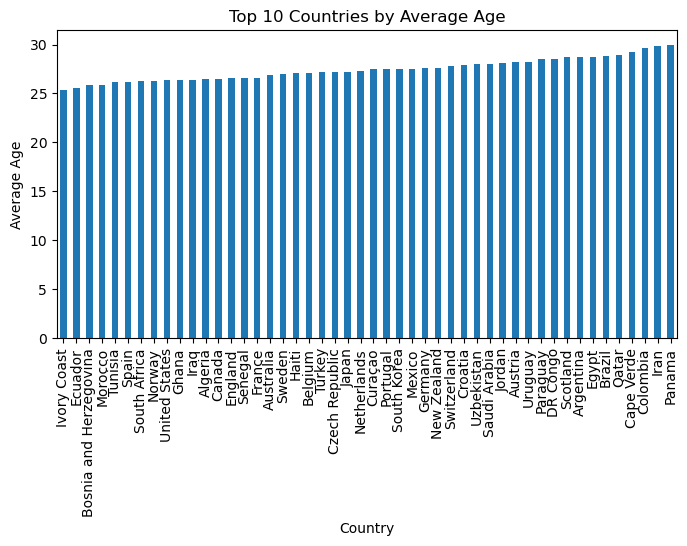

In [12]:
from pyspark.sql import functions as F

avg_age_by_country = (
    spark.table("worldcup_squads_all")
    .withColumn("age", F.regexp_extract(F.col("date_of_birth_age"), r"aged\s+(\d+)", 1).cast("int"))
    .filter(F.col("age").isNotNull())
    .groupBy("country")
    .agg(F.round(F.avg("age"), 1).alias("avg_age"))
    .orderBy(F.asc("avg_age"))
    .limit(50)
)

df = avg_age_by_country.toPandas()

ax = df.plot(kind="bar", x="country", y="avg_age", figsize=(8,4), legend=False, title="Top 10 Countries by Average Age")
ax.set_xlabel("Country")
ax.set_ylabel("Average Age")

# 2026 FIFA World Cup Squads - Lakehouse Script

## Script: Average Age by Country, Grouped by World Cup Group

### What this script does
Calculates average age per country, keeps a limited subset, and colors bars by group.

### Output
Grouped bar chart with value labels and legend.

### Findings
The grouped view makes cross-group comparison easier. In this sample, some Group B and Group C teams appear older than Group A teams, while the overall spread remains moderate.

StatementMeta(, 9aaa225e-2b3e-4467-8716-af5588f4f881, 24, Finished, Available, Finished, False)

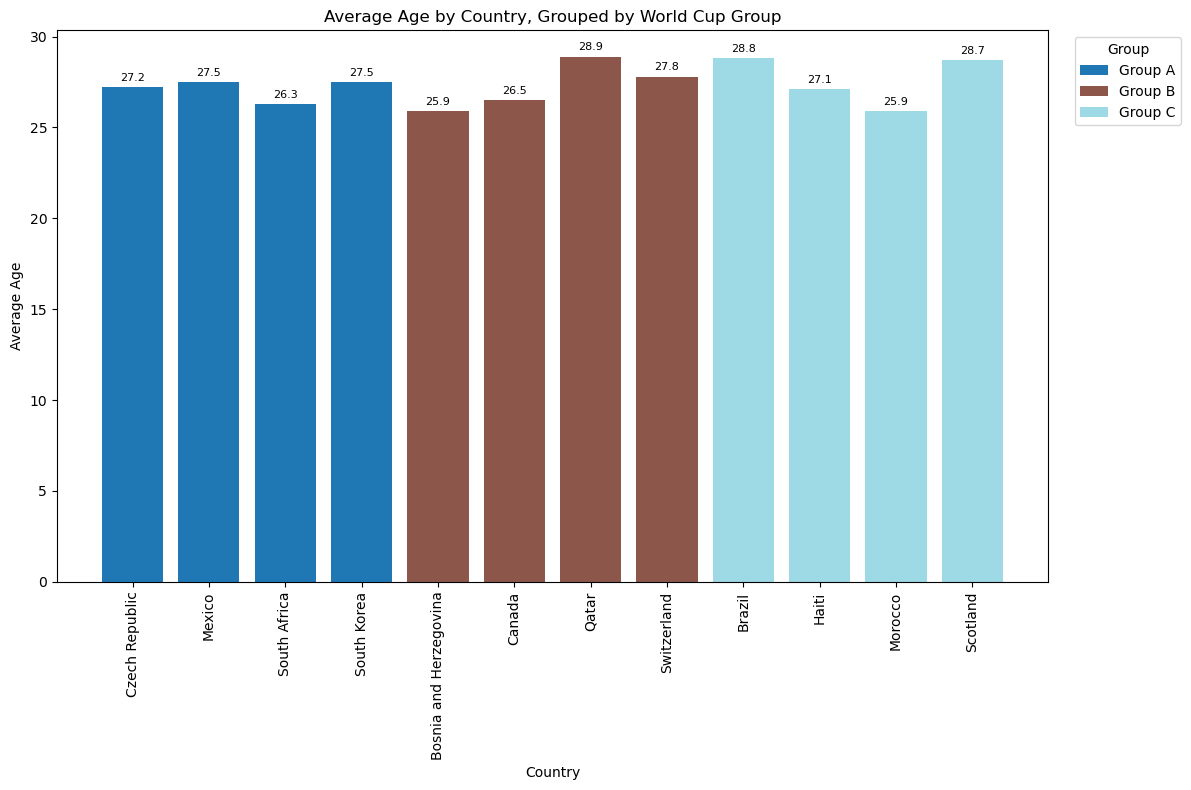

In [11]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

avg_age_by_country = (
    spark.table("worldcup_squads_all")
    .withColumn("age", F.regexp_extract(F.col("date_of_birth_age"), r"aged\s+(\d+)", 1).cast("int"))
    .filter(F.col("age").isNotNull())
    .groupBy("group", "country")
    .agg(F.round(F.avg("age"), 1).alias("avg_age"))
    .orderBy(F.asc("group"), F.asc("country"))
    .limit(12)
)

df = avg_age_by_country.toPandas()

fig, ax = plt.subplots(figsize=(12, 8))

group_order = list(df["group"].astype("category").cat.categories)
palette = plt.get_cmap("tab20", len(group_order))
color_map = {group: palette(i) for i, group in enumerate(group_order)}

bars = ax.bar(df["country"], df["avg_age"], color=df["group"].map(color_map))

ax.set_title("Average Age by Country, Grouped by World Cup Group")
ax.set_xlabel("Country")
ax.set_ylabel("Average Age")
ax.tick_params(axis="x", rotation=90)

ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)

legend_items = [Patch(facecolor=color_map[group], label=group) for group in group_order]
ax.legend(handles=legend_items, title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

# 2026 FIFA World Cup Squads - Lakehouse Script

## Script: Youngest vs Oldest Squads (Country Averages)

### What this script does
Builds two segments from country-level average age:
- 5 youngest squads
- 5 oldest squads

### Output
Single comparison chart with segment colors and value labels (`age | group`).

### Findings
The split view highlights the gap between extremes more clearly than one long ranking. In this run, the spread between youngest and oldest averages is roughly three years.

StatementMeta(, 9aaa225e-2b3e-4467-8716-af5588f4f881, 39, Finished, Available, Finished, False)

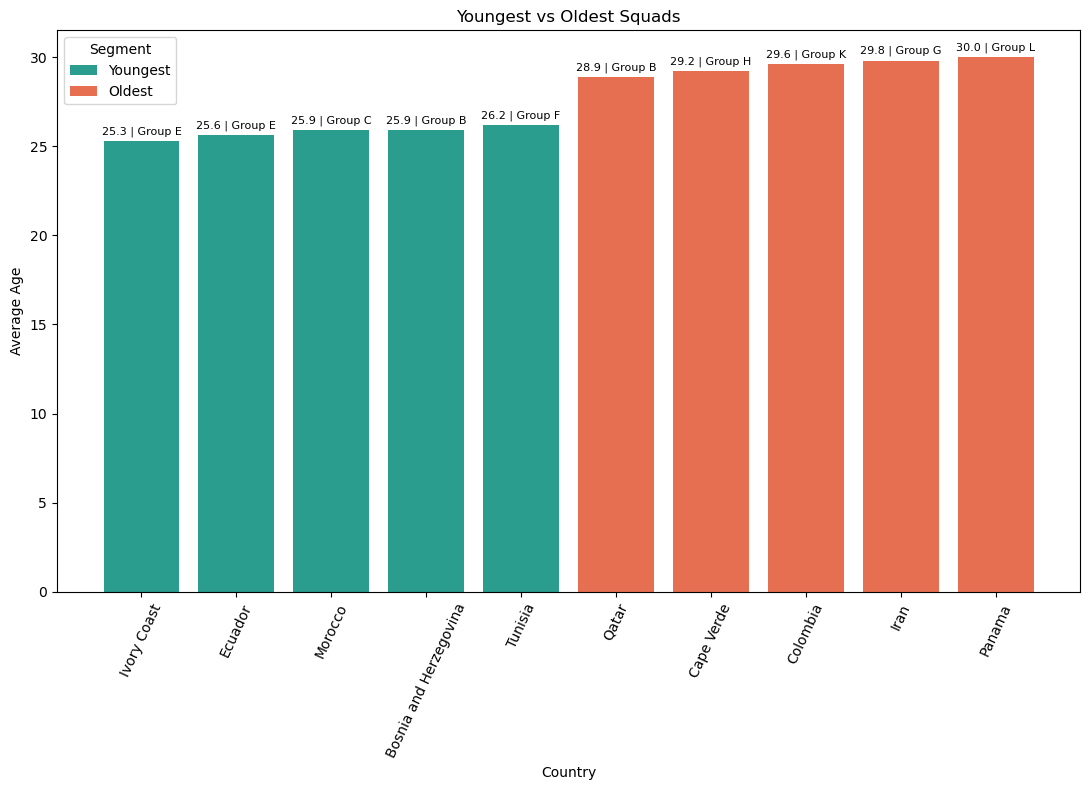

In [25]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

base = (
    spark.table("worldcup_squads_all")
    .withColumn("age", F.regexp_extract(F.col("date_of_birth_age"), r"aged\s+(\d+)", 1).cast("int"))
    .filter(F.col("age").isNotNull())
    .groupBy("group", "country")
    .agg(F.round(F.avg("age"), 1).alias("avg_age"))
)

oldest = (
    base.orderBy(F.desc("avg_age"))
    .limit(5)
    .withColumn("segment", F.lit("Oldest"))
)

youngest = (
    base.orderBy(F.asc("avg_age"))
    .limit(5)
    .withColumn("segment", F.lit("Youngest"))
)

df = oldest.unionByName(youngest).toPandas()

# Optional: sort for cleaner visual order (youngest first, then oldest)
df["segment_order"] = df["segment"].map({"Youngest": 0, "Oldest": 1})
df = df.sort_values(["segment_order", "avg_age"], ascending=[True, True]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))

segment_colors = {"Youngest": "#2a9d8f", "Oldest": "#e76f51"}
bar_colors = df["segment"].map(segment_colors)

bars = ax.bar(df["country"], df["avg_age"], color=bar_colors)

ax.set_title("Youngest vs Oldest Squads")
ax.set_xlabel("Country")
ax.set_ylabel("Average Age")
ax.tick_params(axis="x", rotation=65)

# Label above each bar: "age | group"
labels = [f"{age:.1f} | {grp}" for age, grp in zip(df["avg_age"], df["group"])]
ax.bar_label(bars, labels=labels, padding=3, fontsize=8, rotation=360)

legend_items = [
    Patch(facecolor=segment_colors["Youngest"], label="Youngest"),
    Patch(facecolor=segment_colors["Oldest"], label="Oldest"),
]
ax.legend(handles=legend_items, title="Segment", loc="upper left")

plt.tight_layout()

# 2026 FIFA World Cup Squads - Lakehouse Script

## Script: Average Age by Group

### What this script does
Calculates average age for each World Cup group and plots the result.

### Output
Bar chart with exact value labels above each bar.

### Findings
Group-level age differences exist, but they are relatively small. This view is useful for comparing overall age profiles without country-level detail.

StatementMeta(, 9aaa225e-2b3e-4467-8716-af5588f4f881, 43, Finished, Available, Finished, False)

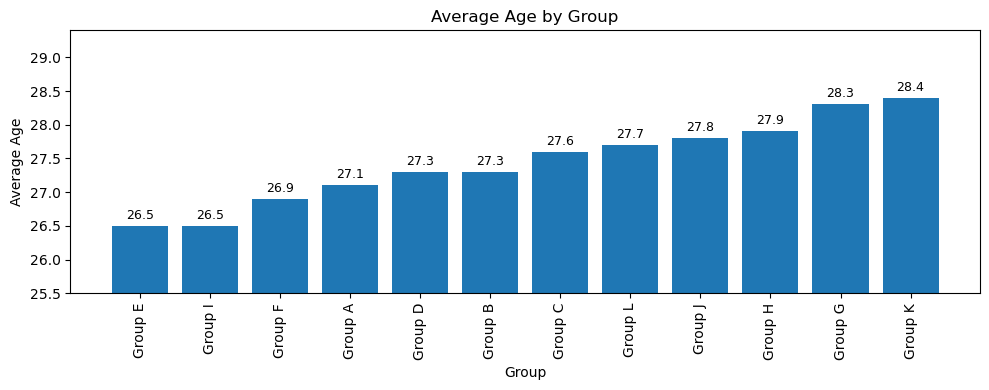

In [28]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

avg_age_by_group = (
    spark.table("worldcup_squads_all")
    .withColumn("age", F.regexp_extract(F.col("date_of_birth_age"), r"aged\s+(\d+)", 1).cast("int"))
    .filter(F.col("age").isNotNull())
    .groupBy("group")
    .agg(F.round(F.avg("age"), 1).alias("avg_age"))
    .orderBy("avg_age")
)

df = avg_age_by_group.toPandas()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df["group"], df["avg_age"])

ax.set_title("Average Age by Group")
ax.set_xlabel("Group")
ax.set_ylabel("Average Age")

# Optional: zoom y-axis a bit so tiny differences are easier to see
ymin = max(0, df["avg_age"].min() - 1)
ymax = df["avg_age"].max() + 1
ax.set_ylim(ymin, ymax)

# Add exact values on top of bars
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 2026 FIFA World Cup Squads - Lakehouse Script

## Script: Most Capped Players (Tournament Leaders)

### What this script does
Extracts numeric caps and ranks players by total caps across the full tournament dataset.

### Output
Horizontal bar chart of the top 10 most capped players.

### Findings
This chart highlights the most experienced internationals and makes label reading easier with a horizontal layout.

StatementMeta(, 6dd4663a-aa57-4c3e-9c27-d7c10fcd1e86, 6, Finished, Available, Finished, False)

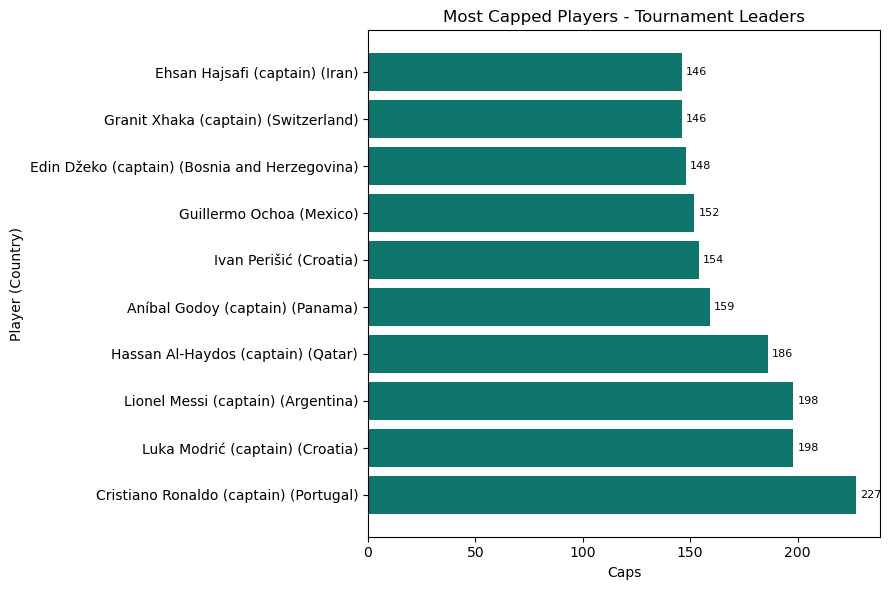

In [3]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

# 1) Load table and pick the first caps-like column that actually exists.
source = spark.table("worldcup_squads_all")
caps_candidates = ["caps", "apps", "appearances"]
existing_caps_cols = [c for c in caps_candidates if c in source.columns]

if not existing_caps_cols:
    raise ValueError(
        "No caps column found. Expected one of: caps, apps, appearances. "
        f"Available columns: {source.columns}"
    )

caps_col = existing_caps_cols[0]

# 2) Parse caps as integer from common formats, e.g. 123 or "123 (45)".
caps_base = (
    source
    .withColumn(
        "caps_num",
        F.regexp_extract(
            F.coalesce(F.col(caps_col).cast("string"), F.lit("")),
            r"(\d+)",
            1,
        ).cast("int"),
    )
    .filter(F.col("caps_num").isNotNull())
    .select("group", "country", "player", "caps_num")
)

# 3) View 1: Most capped players in the tournament
top_overall = (
    caps_base
    .orderBy(F.desc("caps_num"), F.asc("player"))
    .limit(10)
)

pdf_overall = top_overall.toPandas()
pdf_overall["label"] = pdf_overall["player"] + " (" + pdf_overall["country"] + ")"

# Horizontal version (readable labels)
# Sort so the largest value appears at the top after invert_yaxis
pdf_overall = pdf_overall.sort_values("caps_num", ascending=True)

fig1, ax1 = plt.subplots(figsize=(9, 6))
bars1 = ax1.barh(pdf_overall["label"], pdf_overall["caps_num"], color="#0F766E")

ax1.set_title("Most Capped Players - Tournament Leaders")
ax1.set_xlabel("Caps")
ax1.set_ylabel("Player (Country)")

# Put value labels at the end of each horizontal bar
ax1.bar_label(bars1, fmt="%d", padding=3, fontsize=8)

# Highest caps at the top
ax1.invert_yaxis()

plt.tight_layout()
plt.show()

# 2026 FIFA World Cup Squads - Lakehouse Script

## Script: Top 3 Most Capped Players in Each Team

### What this script does
Ranks players by caps within each country and keeps the top three.

### Output
Spark table output with:
- `country`
- `rank_in_country`
- `player`
- `caps_num`

### Findings
This section reveals how experience is distributed inside each squad and helps identify teams with a strong veteran core.

In [8]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

# 1) Load table and pick the first caps-like column that actually exists.
source = spark.table("worldcup_squads_all")
caps_candidates = ["caps", "apps", "appearances"]
existing_caps_cols = [c for c in caps_candidates if c in source.columns]

if not existing_caps_cols:
    raise ValueError(
        "No caps column found. Expected one of: caps, apps, appearances. "
        f"Available columns: {source.columns}"
    )

caps_col = existing_caps_cols[0]

# 2) Parse caps as integer from common formats, e.g. 123 or "123 (45)".
caps_base = (
    source
    .withColumn(
        "caps_num",
        F.regexp_extract(
            F.coalesce(F.col(caps_col).cast("string"), F.lit("")),
            r"(\d+)",
            1,
        ).cast("int"),
    )
    .filter(F.col("caps_num").isNotNull())
    .select("group", "country", "player", "caps_num")
)
# 3) View : Most capped players within each team (top 3 per country) as a table

w = Window.partitionBy("country").orderBy(F.desc("caps_num"), F.asc("player"))

top_within_team = (
    caps_base
    .withColumn("rank_in_country", F.row_number().over(w))
    .filter(F.col("rank_in_country") <= 3)
    .orderBy(F.asc("country"), F.asc("rank_in_country"))
)

# Table output in Spark (best for long lists)
top_within_team.select("country", "rank_in_country", "player", "caps_num").show(300, truncate=False)


StatementMeta(, 6dd4663a-aa57-4c3e-9c27-d7c10fcd1e86, 12, Finished, Available, Finished, False)

+----------------------+---------------+---------------------------+--------+
|country               |rank_in_country|player                     |caps_num|
+----------------------+---------------+---------------------------+--------+
|Algeria               |1              |Aïssa Mandi                |117     |
|Algeria               |2              |Riyad Mahrez (captain)     |114     |
|Algeria               |3              |Ramy Bensebaini            |81      |
|Argentina             |1              |Lionel Messi (captain)     |198     |
|Argentina             |2              |Nicolás Otamendi           |131     |
|Argentina             |3              |Rodrigo De Paul            |86      |
|Australia             |1              |Mathew Ryan (captain)      |104     |
|Australia             |2              |Aziz Behich                |84      |
|Australia             |3              |Jackson Irvine             |82      |
|Austria               |1              |Marko Arnautović        

In [9]:
# Optional: compact pivot table (one row per country, columns for top 1/2/3)
pdf_team = top_within_team.select("country", "rank_in_country", "player", "caps_num").toPandas()
pdf_team["player_caps"] = pdf_team["player"] + " (" + pdf_team["caps_num"].astype(str) + ")"

pivot = (
    pdf_team
    .pivot(index="country", columns="rank_in_country", values="player_caps")
    .rename(columns={1: "Top 1", 2: "Top 2", 3: "Top 3"})
    .reset_index()
    .sort_values("country")
)

print("\nTop 3 Most Capped Players in Each Team")
print(pivot.to_string(index=False))

StatementMeta(, 6dd4663a-aa57-4c3e-9c27-d7c10fcd1e86, 13, Finished, Available, Finished, False)


Top 3 Most Capped Players in Each Team
               country                             Top 1                           Top 2                             Top 3
               Algeria                 Aïssa Mandi (117)    Riyad Mahrez (captain) (114)              Ramy Bensebaini (81)
             Argentina      Lionel Messi (captain) (198)          Nicolás Otamendi (131)              Rodrigo De Paul (86)
             Australia       Mathew Ryan (captain) (104)                Aziz Behich (84)               Jackson Irvine (82)
               Austria            Marko Arnautović (133)     David Alaba (captain) (113)              Marcel Sabitzer (98)
               Belgium                 Axel Witsel (138)             Romelu Lukaku (126)             Kevin De Bruyne (119)
Bosnia and Herzegovina        Edin Džeko (captain) (148)             Sead Kolašinac (65)            Ermedin Demirović (40)
                Brazil                      Neymar (128)      Marquinhos (captain) (105)           

# 2026 FIFA World Cup Squads - Lakehouse Script

## Script: Age vs Caps Correlation (Grouped by Position)

### What this script does
Tests whether older players generally have more caps by plotting age vs caps and adding:
- position-based color grouping
- trend line
- Pearson correlation

### Output
Scatter plot with legend and correlation annotation.

### Findings
The trend line slopes upward, indicating a positive relationship between age and caps. The relationship is meaningful but not perfect, which suggests that factors beyond age also influence experience.

StatementMeta(, 7b4f9869-bcb1-4fd1-94ea-04ed84eef716, 22, Finished, Available, Finished, False)

Rows used for scatter: 1246


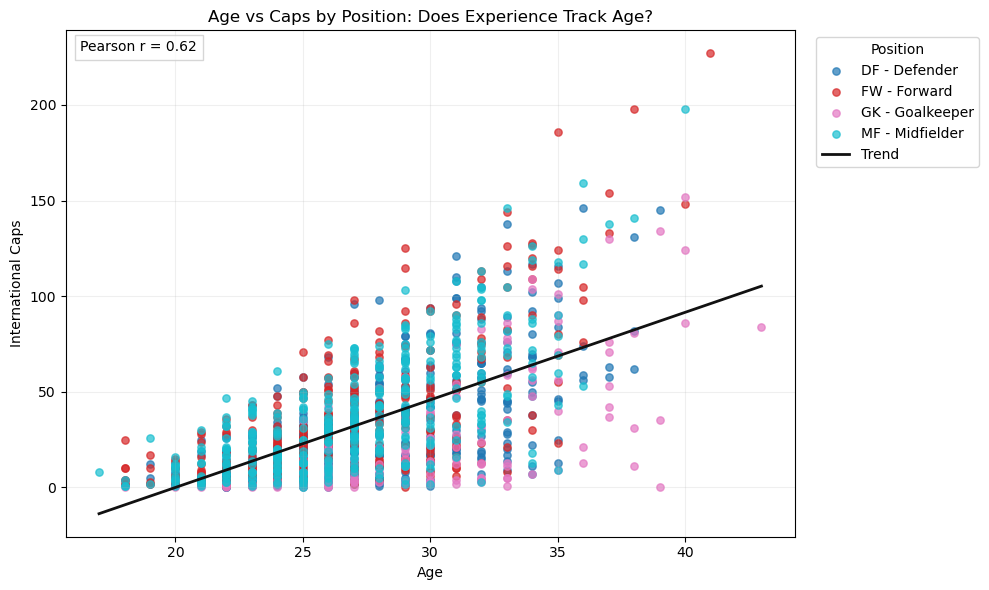

In [4]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np

# 1) Load source table
source = spark.table("worldcup_squads_all")

# 2) Resolve which caps column exists
caps_candidates = ["caps", "apps", "appearances"]
existing_caps_cols = [c for c in caps_candidates if c in source.columns]

if not existing_caps_cols:
    raise ValueError(
        "No caps column found. Expected one of: caps, apps, appearances. "
        f"Available columns: {source.columns}"
    )

caps_col = existing_caps_cols[0]

# Position label mapping
pos_meaning = {
    "GK": "Goalkeeper",
    "DF": "Defender",
    "MF": "Midfielder",
    "FW": "Forward",
}
# Optional fallback used if another code appears
def to_pos_label(code):
    code = str(code).strip().upper()
    return f"{code} - {pos_meaning.get(code, 'Other/Unknown')}"

# 3) Build analysis dataset with clean numeric fields
analysis_df = (
    source
    .withColumn("age", F.regexp_extract(F.col("date_of_birth_age"), r"aged\s+(\d+)", 1).cast("int"))
    .withColumn("caps_num", F.regexp_extract(F.col(caps_col).cast("string"), r"(\d+)", 1).cast("int"))
    .withColumn("pos_norm", F.upper(F.trim(F.col("pos"))))
    .filter(F.col("age").isNotNull() & F.col("caps_num").isNotNull() & F.col("pos_norm").isNotNull())
    .select("pos_norm", "country", "player", "age", "caps_num")
)

print("Rows used for scatter:", analysis_df.count())

# 4) Move to pandas for plotting
pdf = analysis_df.toPandas()

# 5) Scatter plot colored by position
fig, ax = plt.subplots(figsize=(10, 6))

positions = sorted(pdf["pos_norm"].dropna().unique().tolist())
palette = plt.get_cmap("tab10", len(positions))
color_map = {p: palette(i) for i, p in enumerate(positions)}

for p in positions:
    part = pdf[pdf["pos_norm"] == p]
    ax.scatter(
        part["age"],
        part["caps_num"],
        s=28,
        alpha=0.7,
        color=color_map[p],
        label=to_pos_label(p),   # <- abbreviation + meaning in legend
    )

# 6) Add trend line + Pearson correlation
x = pdf["age"].to_numpy(dtype=float)
y = pdf["caps_num"].to_numpy(dtype=float)

if len(pdf) >= 2:
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color="#111111", linewidth=2, label="Trend")

    corr = float(np.corrcoef(x, y)[0, 1])
    ax.text(
        0.02,
        0.98,
        f"Pearson r = {corr:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "#cccccc"},
    )

ax.set_title("Age vs Caps by Position: Does Experience Track Age?")
ax.set_xlabel("Age")
ax.set_ylabel("International Caps")
ax.grid(alpha=0.2)
ax.legend(title="Position", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# 2026 FIFA World Cup Squads - Lakehouse Script

## Script: Top 5 Players by Goals in Each Position

### What this script does
Creates a position-level goals analysis:
1. Position summary table (`players_count`, `players_with_goals`, `total_goals`)
2. Top 5 goalscorers per position
3. Multi-panel chart view (with GK excluded from view when requested)

### Output
- Spark summary table
- Spark top-5 table
- Horizontal subplot charts by position

### Findings
For this dataset, attacking and midfield roles dominate goal totals. When goalkeeper totals are zero, the script reports that clearly and can exclude GK from the chart view for readability.

StatementMeta(, 7b4f9869-bcb1-4fd1-94ea-04ed84eef716, 135, Finished, Available, Finished, False)

Goals summary by position:
+--------+-------------+-----------+------------------+
|pos_norm|players_count|total_goals|players_with_goals|
+--------+-------------+-----------+------------------+
|DF      |420          |653        |234               |
|FW      |310          |3436       |272               |
|GK      |145          |0          |0                 |
|MF      |371          |1470       |275               |
+--------+-------------+-----------+------------------+

No data (0 total goals) for positions: GK
Top 5 players by goals in each position:
+--------+----------------+---------------------------+------------+---------+
|pos_norm|rank_in_position|player_name                |country_name|goals_num|
+--------+----------------+---------------------------+------------+---------+
|DF      |1               |Boualem Khoukhi            |Qatar       |20       |
|DF      |2               |Alphonso Davies (captain)  |Canada      |15       |
|DF      |3               |David Alaba (captai

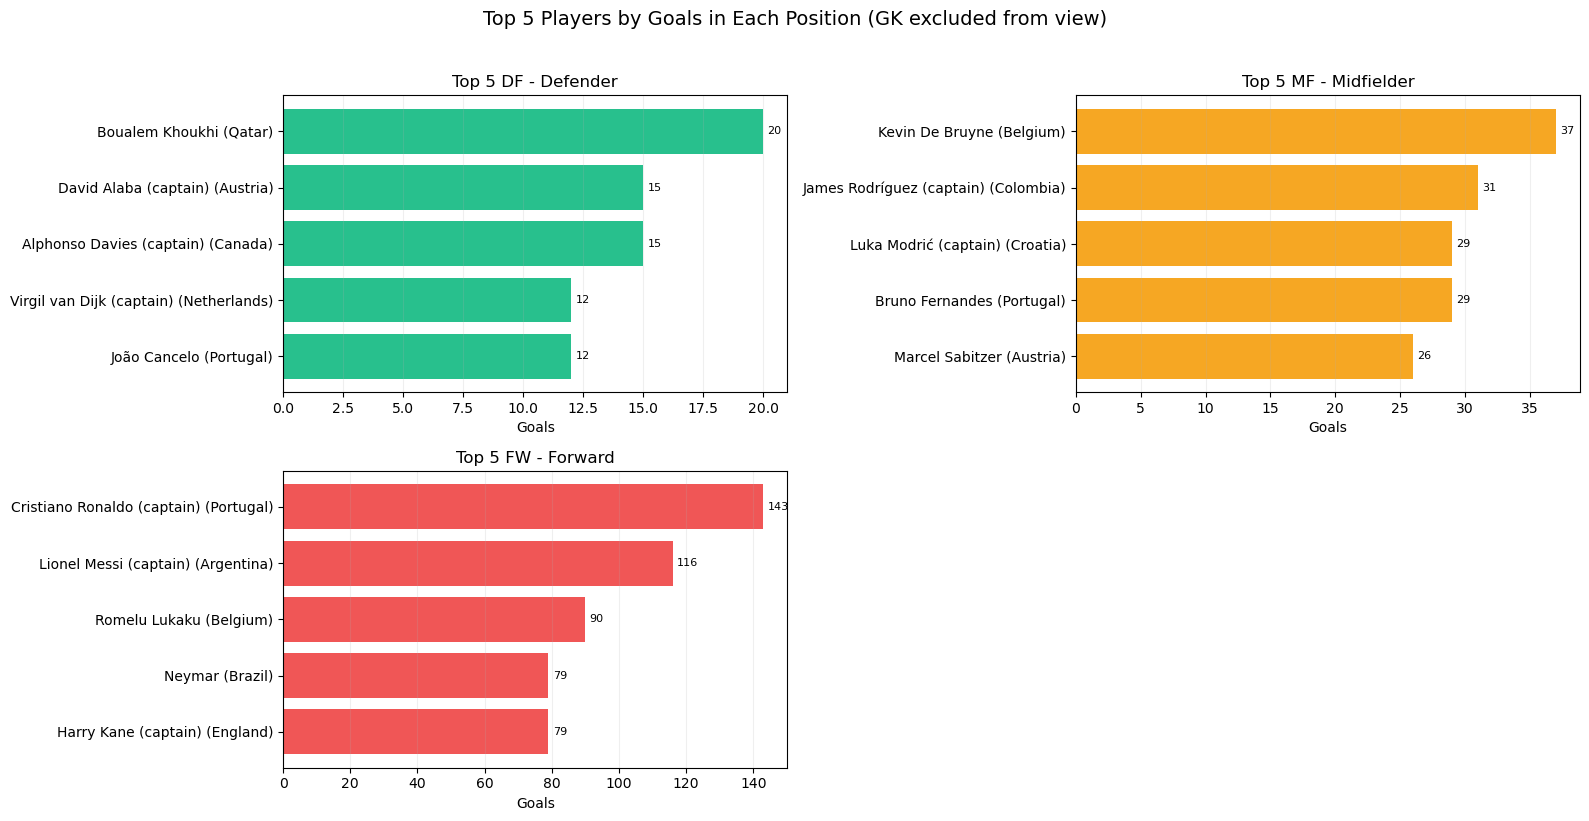

In [31]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import math

# 1) Load source table
source = spark.table("worldcup_squads_all")

# 2) Resolve goals column safely
goals_candidates = ["goals", "goal"]
existing_goals_cols = [c for c in goals_candidates if c in source.columns]

if not existing_goals_cols:
    raise ValueError(
        "No goals column found. Expected one of: goals, goal. "
        f"Available columns: {source.columns}"
    )

goals_col = existing_goals_cols[0]

# 3) Clean and normalize fields
base = (
    source
    .withColumn("pos_norm", F.upper(F.trim(F.col("pos"))))
    .withColumn("player_name", F.trim(F.col("player")))
    .withColumn("country_name", F.trim(F.col("country")))
    .withColumn("goals_num", F.regexp_extract(F.col(goals_col).cast("string"), r"(\d+)", 1).cast("int"))
    .filter(F.col("pos_norm").isNotNull() & (F.col("pos_norm") != ""))
    .filter(F.col("player_name").isNotNull() & (F.col("player_name") != ""))
)

# 4) Position summary (includes zeros and keeps GK for audit)
pos_master = spark.createDataFrame([("GK",), ("DF",), ("MF",), ("FW",)], ["pos_norm"])

summary = (
    pos_master
    .join(
        base.groupBy("pos_norm").agg(
            F.count("*").alias("players_count"),
            F.sum(F.coalesce(F.col("goals_num"), F.lit(0))).alias("total_goals"),            
            F.sum(F.when(F.col("goals_num") > 0, 1).otherwise(0)).alias("players_with_goals")
        ),
        on="pos_norm",
        how="left"
    )
    .fillna(0, subset=["players_count", "total_goals", "players_with_goals"])
    .orderBy("pos_norm")
)

print("Goals summary by position:")
summary.show(truncate=False)

# Print explicit no-data / zero-goal message
no_data_positions = [r["pos_norm"] for r in summary.filter(F.col("total_goals") == 0).collect()]
if no_data_positions:
    print("No data (0 total goals) for positions:", ", ".join(no_data_positions))

# 5) Rank top 5 players by goals within each position
ranked_base = base.filter(F.col("goals_num").isNotNull())

w = Window.partitionBy("pos_norm").orderBy(F.desc("goals_num"), F.asc("player_name"))

top5_each_position = (
    ranked_base
    .withColumn("rank_in_position", F.row_number().over(w))
    .filter((F.col("rank_in_position") <= 5) & (F.col("pos_norm") != "GK"))
    .select("pos_norm", "rank_in_position", "player_name", "country_name", "goals_num")
    .orderBy(F.asc("pos_norm"), F.asc("rank_in_position"))
)

print("Top 5 players by goals in each position:")
top5_each_position.show(200, truncate=False)

# 6) Chart view only: exclude GK
pdf = top5_each_position.toPandas()
plot_pdf = pdf[pdf["pos_norm"] != "GK"].copy()

print("GK excluded from chart view only.")

if plot_pdf.empty:
    print("No non-GK data available to plot.")
else:
    pos_names = {
        "GK": "Goalkeeper",
        "DF": "Defender",
        "MF": "Midfielder",
        "FW": "Forward",
    }

    colors = {
        "DF": "#10B981",  # green
        "MF": "#F59E0B",  # amber
        "FW": "#EF4444",  # red
    }

    # Order common positions first
    ordered_positions = [p for p in ["DF", "MF", "FW"] if p in plot_pdf["pos_norm"].unique()]
    extra_positions = sorted([p for p in plot_pdf["pos_norm"].unique() if p not in ordered_positions])
    positions = ordered_positions + extra_positions

    n = len(positions)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, pos in enumerate(positions):
        ax = axes[i]
        part = plot_pdf[plot_pdf["pos_norm"] == pos].copy().sort_values("goals_num", ascending=True)
        part["label"] = part["player_name"] + " (" + part["country_name"] + ")"

        bars = ax.barh(
            part["label"],
            part["goals_num"],
            color=colors.get(pos, "#6B7280"),
            alpha=0.9
        )

        ax.set_title(f"Top 5 {pos} - {pos_names.get(pos, 'Other')}")
        ax.set_xlabel("Goals")
        ax.grid(axis="x", alpha=0.2)
        ax.bar_label(bars, fmt="%d", padding=3, fontsize=8)

    # Hide empty subplot slots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Top 5 Players by Goals in Each Position (GK excluded from view)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()